<a href="https://colab.research.google.com/github/Rafa-Cami/CD-Norton/blob/main/EP3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

vamos começar LET'S GO BITCHESSSSS

# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV, learning_curve
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_curve, auc, precision_recall_curve, roc_auc_score, precision_score, recall_score

# Seed

Seed definida para garantir reprodutibilidade

In [2]:
seed = 42

random.seed(seed)
np.random.seed(seed)

### Importando o conjunto de dados 

In [4]:
df = pd.read_csv('subamostra_90_porcento.csv')
df.head(50)

,age,gender,marital_status,education_level,employment_status,sleep_hours,physical_activity_hours_per_week,screen_time_hours_per_day,social_support_score,work_stress_level,...,depression_score,stress_level,mood_swings_frequency,concentration_difficulty_level,panic_attack_history,family_history_mental_illness,previous_mental_health_diagnosis,therapy_history,substance_use,mental_health_risk
0,47,Female,Single,High School,Unemployed,5.3,1.5,7.2,8,5,...,5,4,6,3,1,1,1,1,0,1
1,53,Other,Single,Bachelor,Employed,4.8,0.5,5.6,8,4,...,7,1,2,5,1,1,0,0,0,2
2,43,Male,Single,Bachelor,Student,6.4,6.9,10.2,4,1,...,8,9,9,5,1,0,1,1,0,1
3,18,Other,Married,High School,Unemployed,9.6,0.4,7.4,6,6,...,7,5,7,3,0,0,1,0,1,0
4,23,Female,Divorced,Master,Self-Employed,9.0,1.3,5.1,6,3,...,4,5,7,7,0,1,0,0,0,0
5,53,Female,Married,High School,Unemployed,7.9,14.3,6.9,8,5,...,3,6,8,10,0,0,0,0,1,0
6,45,Other,Married,Master,Student,8.2,2.0,3.0,2,8,...,2,7,1,3,0,1,0,1,1,1
7,23,Other,Divorced,Master,Employed,7.8,4.7,9.1,7,6,...,6,10,3,7,0,0,1,1,1,0
8,42,Other,Single,Bachelor,Student,9.5,9.0,9.8,7,2,...,8,3,6,1,1,1,1,1,0,1
9,34,Female,Divorced,PhD,Employed,6.7,5.2,2.6,7,8,...,8,8,10,6,1,1,0,1,1,2


# Funções de plots das métricas

# Tratamento da base

### Tratamento das variáveis categóricas texto para numéricas

Mapeamento manual Ordinal encoding para não perder a ordem lógica da variável `education_level`

In [5]:
# Defina a ordem correta baseada nos dados que você tem
mapa_educacao = {
    'High School': 1,
    'Bachelor': 2,
    'Master': 3,
    'PhD': 4  # adicione outras categorias se houver
}

df_edu = df.copy()

df_edu['education_level'] = df_edu['education_level'].map(mapa_educacao)
df_edu.head(10)


,age,gender,marital_status,education_level,employment_status,sleep_hours,physical_activity_hours_per_week,screen_time_hours_per_day,social_support_score,work_stress_level,...,depression_score,stress_level,mood_swings_frequency,concentration_difficulty_level,panic_attack_history,family_history_mental_illness,previous_mental_health_diagnosis,therapy_history,substance_use,mental_health_risk
0,47,Female,Single,1,Unemployed,5.3,1.5,7.2,8,5,...,5,4,6,3,1,1,1,1,0,1
1,53,Other,Single,2,Employed,4.8,0.5,5.6,8,4,...,7,1,2,5,1,1,0,0,0,2
2,43,Male,Single,2,Student,6.4,6.9,10.2,4,1,...,8,9,9,5,1,0,1,1,0,1
3,18,Other,Married,1,Unemployed,9.6,0.4,7.4,6,6,...,7,5,7,3,0,0,1,0,1,0
4,23,Female,Divorced,3,Self-Employed,9.0,1.3,5.1,6,3,...,4,5,7,7,0,1,0,0,0,0
5,53,Female,Married,1,Unemployed,7.9,14.3,6.9,8,5,...,3,6,8,10,0,0,0,0,1,0
6,45,Other,Married,3,Student,8.2,2.0,3.0,2,8,...,2,7,1,3,0,1,0,1,1,1
7,23,Other,Divorced,3,Employed,7.8,4.7,9.1,7,6,...,6,10,3,7,0,0,1,1,1,0
8,42,Other,Single,2,Student,9.5,9.0,9.8,7,2,...,8,3,6,1,1,1,1,1,0,1
9,34,Female,Divorced,4,Employed,6.7,5.2,2.6,7,8,...,8,8,10,6,1,1,0,1,1,2


One-hot encoding para as variáveis `gender`, `marital_status` e `employment_status`

In [6]:
df_tratado = pd.get_dummies(df_edu, columns=['gender', 'marital_status', 'employment_status'], dtype=int)
df_tratado.head(10)
df_tratado.head(0)

,age,education_level,sleep_hours,physical_activity_hours_per_week,screen_time_hours_per_day,social_support_score,work_stress_level,academic_pressure_level,job_satisfaction_score,financial_stress_level,...,gender_Female,gender_Male,gender_Other,marital_status_Divorced,marital_status_Married,marital_status_Single,employment_status_Employed,employment_status_Self-Employed,employment_status_Student,employment_status_Unemployed


### Verificando a proproção da variavel alvo no conjunto de dados

In [22]:
contagem_risco = df['mental_health_risk'].value_counts()

print(contagem_risco)

mental_health_risk
1    10667
0     8392
2     3441
Name: count, dtype: int64


### Mapeamento das variáveis para os fatores

In [7]:
mapeamento_fatores = {
    # --- Estilo de Vida ---
    'sleep_hours': 'Estilo de Vida',
    'physical_activity_hours_per_week': 'Estilo de Vida',
    'screen_time_hours_per_day': 'Estilo de Vida',
    'substance_use': 'Estilo de Vida',
    
    # --- Psicológico e Emocional ---
    'depression_score': 'Psicológico e Emocional',
    'stress_level': 'Psicológico e Emocional',
    'mood_swings_frequency': 'Psicológico e Emocional',
    'concentration_difficulty_level': 'Psicológico e Emocional',
    
    # --- Socioeconômico e Ocupacional ---
    'age': 'Socioeconômico e Ocupacional',
    'education_level': 'Socioeconômico e Ocupacional',
    'work_stress_level': 'Socioeconômico e Ocupacional',
    'employment_status_Employed': 'Socioeconômico e Ocupacional',
    'employment_status_Self-Employed': 'Socioeconômico e Ocupacional',
    'employment_status_Student': 'Socioeconômico e Ocupacional',
    'employment_status_Unemployed': 'Socioeconômico e Ocupacional',
    
    # --- Suporte Social e Contexto Interpessoal ---
    'social_support_score': 'Suporte Social e Contexto Interpessoal',
    'gender_Female': 'Suporte Social e Contexto Interpessoal',
    'gender_Male': 'Suporte Social e Contexto Interpessoal',
    'gender_Other': 'Suporte Social e Contexto Interpessoal',
    'marital_status_Divorced': 'Suporte Social e Contexto Interpessoal',
    'marital_status_Married': 'Suporte Social e Contexto Interpessoal',
    'marital_status_Single': 'Suporte Social e Contexto Interpessoal',
    
    # --- Histórico Clínico e Comportamental ---
    'panic_attack_history': 'Histórico Clínico e Comportamental',
    'family_history_mental_illness': 'Histórico Clínico e Comportamental',
    'previous_mental_health_diagnosis': 'Histórico Clínico e Comportamental',
    'therapy_history': 'Histórico Clínico e Comportamental'
}

Um pouco desproporcional, cenário onde seria melhor fazer um cross validation estratificado

# XGBoost??

# Random Forest

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Melhores hiperparâmetros: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Accuracy: 0.9748888888888889
F1 macro: 0.9679218110728502

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1679
           1       0.97      0.97      0.97      2133
           2       0.96      0.92      0.94       688

    accuracy                           0.97      4500
   macro avg       0.97      0.96      0.97      4500
weighted avg       0.97      0.97      0.97      4500


Matriz de confusão:
[[1679    0    0]
 [  32 2077   24]
 [   0   57  631]]

Top 20 features importantes:
sleep_hours                         0.170018
panic_attack_history                0.166114
anxiety_score                       0.164907
depression_score                    0.160228
family_history_mental_illness       0.048580
work_stress_level          

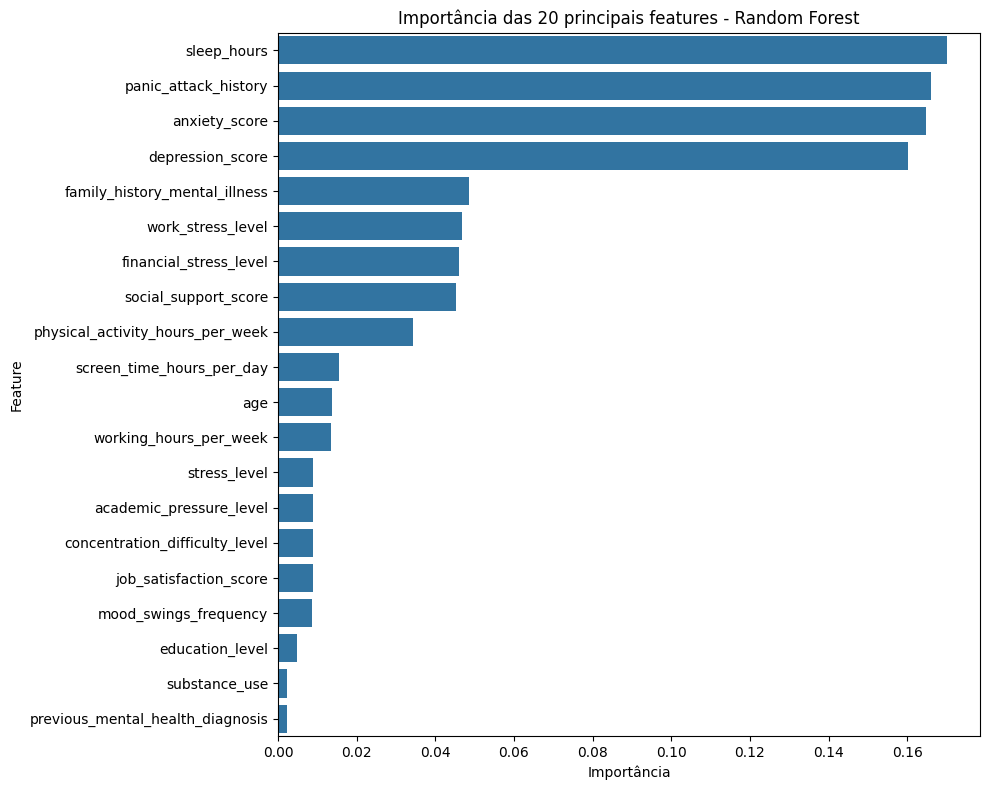

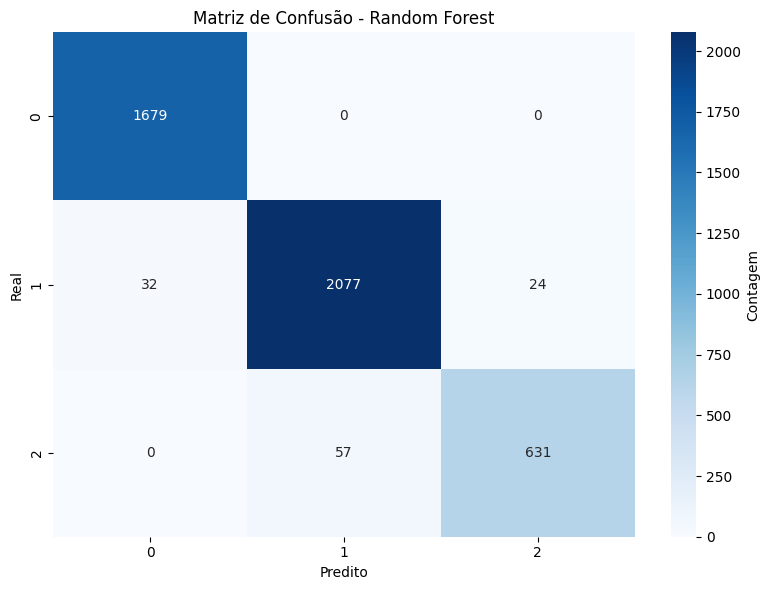

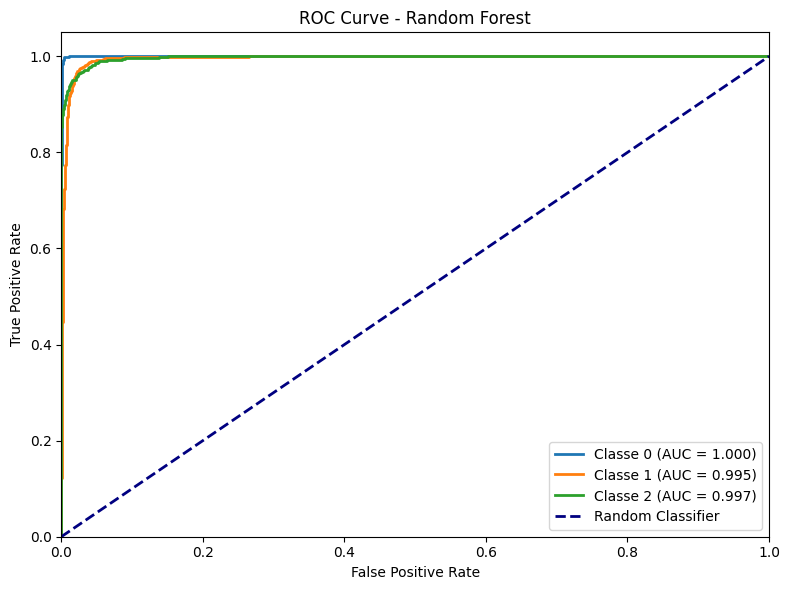

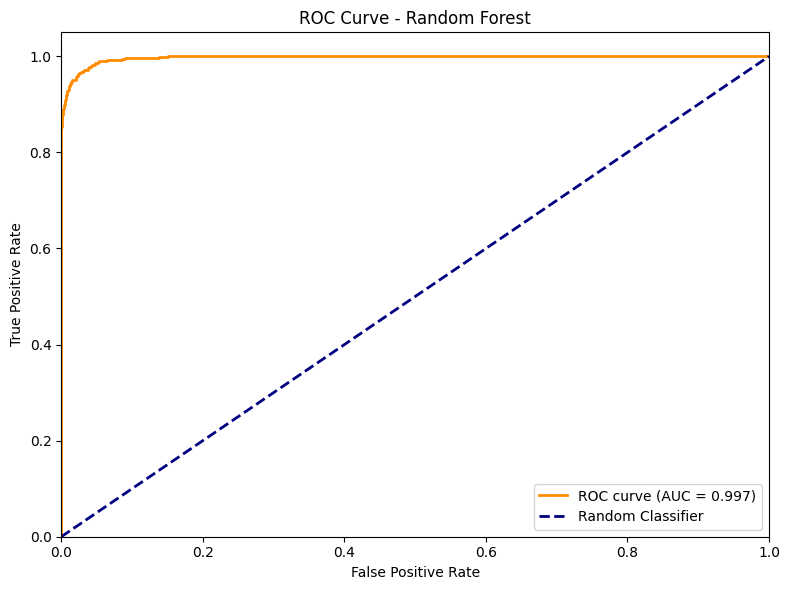

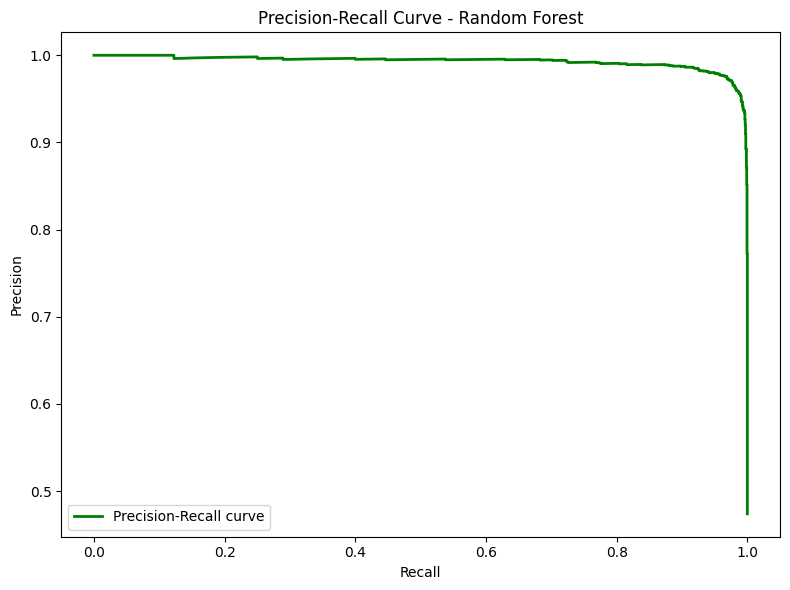


========== MÉTRICAS DETALHADAS - RANDOM FOREST ==========
Precision (macro): 0.9726
Recall (macro): 0.9636
F1 (macro): 0.9679
ROC-AUC (macro, ovr): 0.9973


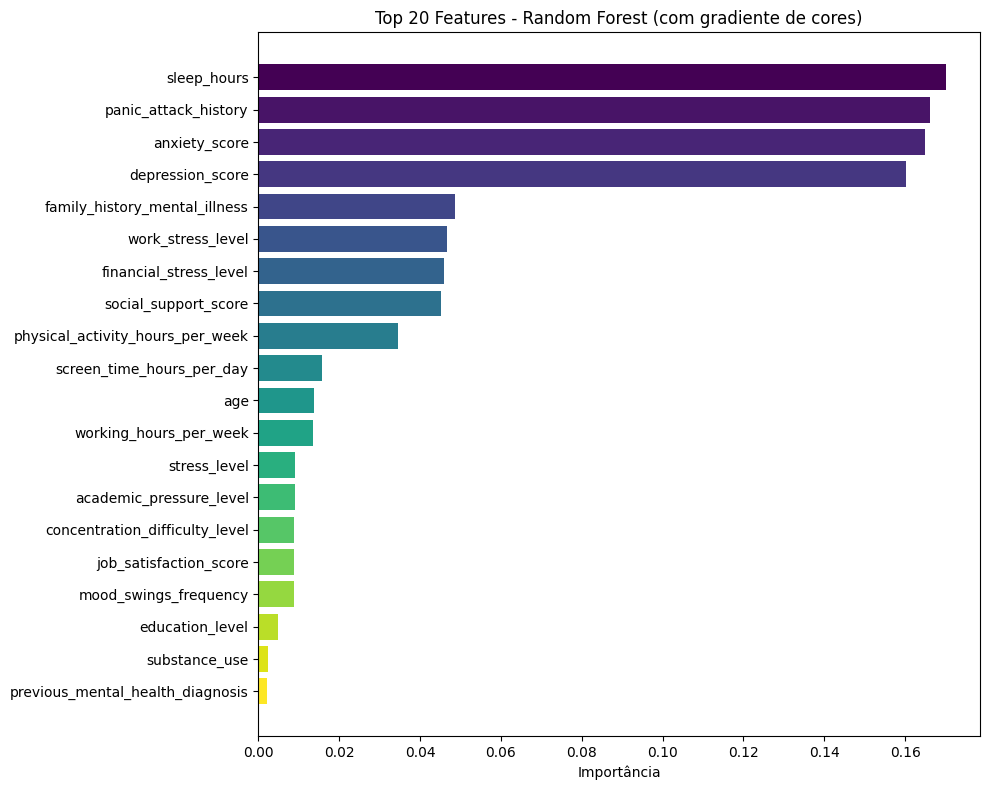

In [11]:
from sklearn.preprocessing import label_binarize

target = 'mental_health_risk'

X = df_tratado.drop(columns=[target])
y = df_tratado[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed, stratify=y
)

rf = RandomForestClassifier(random_state=seed, n_jobs=-1, class_weight='balanced')

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
grid = GridSearchCV(rf, param_grid, cv=cv, scoring='f1_macro', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_
print('Melhores hiperparâmetros:', grid.best_params_)

print('Accuracy:', accuracy_score(y_test, best_rf.predict(X_test)))
print('F1 macro:', f1_score(y_test, best_rf.predict(X_test), average='macro'))

print('\nRelatório de classificação:')
print(classification_report(y_test, best_rf.predict(X_test)))
print('\nMatriz de confusão:')
print(confusion_matrix(y_test, best_rf.predict(X_test)))

feature_importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print('\nTop 20 features importantes:')
print(feature_importances.head(20))

plt.figure(figsize=(10, 8))
sns.barplot(x=feature_importances.head(20), y=feature_importances.head(20).index)
plt.title('Importância das 20 principais features - Random Forest')
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# ========== GRÁFICOS E MÉTRICAS COMPLETAS - RANDOM FOREST ==========

# Predições para gráficos
y_pred_rf = best_rf.predict(X_test)
y_pred_proba_rf = best_rf.predict_proba(X_test)

# 1. Confusion Matrix em heatmap
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar_kws={'label': 'Contagem'})
ax.set_title('Matriz de Confusão - Random Forest')
ax.set_xlabel('Predito')
ax.set_ylabel('Real')
plt.tight_layout()
plt.show()

# 2. ROC Curve e AUC
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

# 2. ROC Curve e AUC
plt.figure(figsize=(8, 6))
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba_rf[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Classe {cls} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# 3. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test_bin.ravel(), y_pred_proba_rf.ravel())

# 4. Métricas por classe
roc_auc_score_val = roc_auc_score(y_test_bin, y_pred_proba_rf, average='macro', multi_class='ovr')
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# 3. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test_bin[:, 1], y_pred_proba_rf[:, 1])
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='green', lw=2, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Random Forest')
plt.legend(loc="best")
plt.tight_layout()
plt.show()

# 4. Métricas por classe
print('\n========== MÉTRICAS DETALHADAS - RANDOM FOREST ==========')
precision_macro = precision_score(y_test, y_pred_rf, average='macro')
recall_macro = recall_score(y_test, y_pred_rf, average='macro')
f1_macro = f1_score(y_test, y_pred_rf, average='macro')
# multiclass AUC: use binarized y_test and full probability matrix
roc_auc_score_val = roc_auc_score(y_test_bin, y_pred_proba_rf, average='macro', multi_class='ovr')

print(f'Precision (macro): {precision_macro:.4f}')
print(f'Recall (macro): {recall_macro:.4f}')
print(f'F1 (macro): {f1_macro:.4f}')
print(f'ROC-AUC (macro, ovr): {roc_auc_score_val:.4f}')

# 5. Gráfico de distribuição de importância
fig, ax = plt.subplots(figsize=(10, 8))
feature_imp_top = feature_importances.head(20)
colors = plt.cm.viridis(np.linspace(0, 1, len(feature_imp_top)))
ax.barh(range(len(feature_imp_top)), feature_imp_top.values, color=colors)
ax.set_yticks(range(len(feature_imp_top)))
ax.set_yticklabels(feature_imp_top.index)
ax.set_xlabel('Importância')
ax.set_title('Top 20 Features - Random Forest (com gradiente de cores)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Ensemble customizado por fatores + Random Forest principal
Combina o Random Forest principal (best_rf) com 5 Random Forests por fator (5 árvores cada). Total: ~225 árvores votando

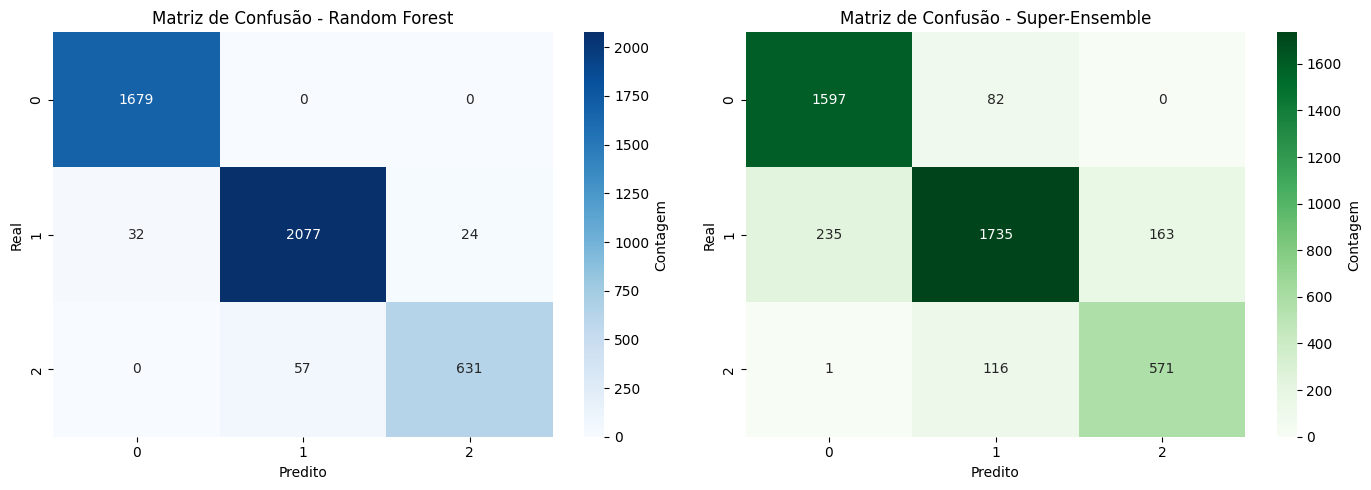

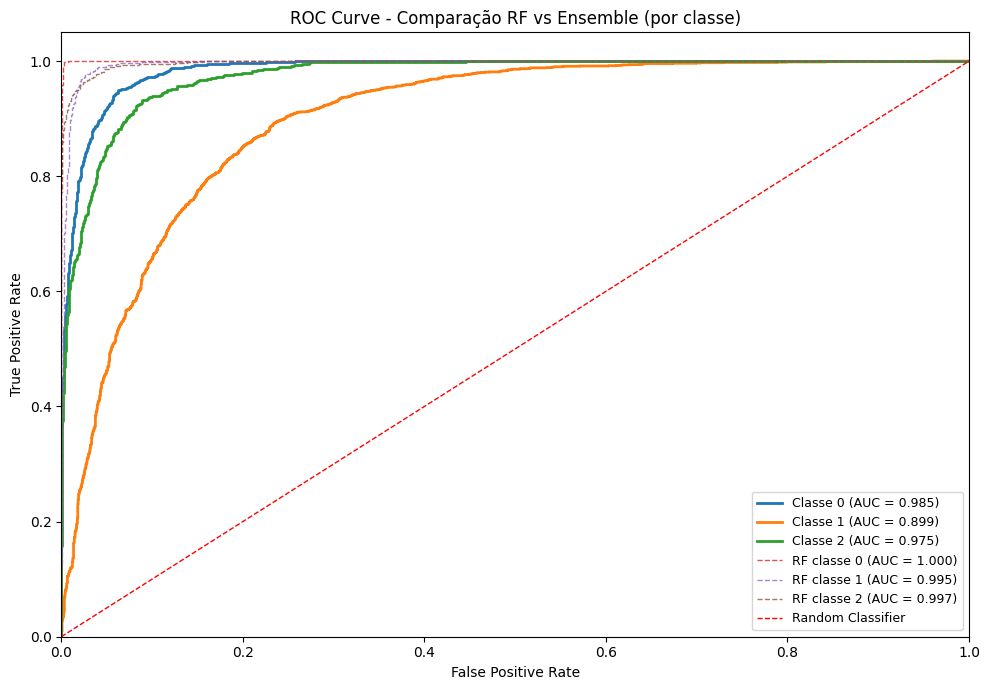

ROC-AUC RF (macro OVR): 0.9973
ROC-AUC Ensemble (macro OVR): 0.9529


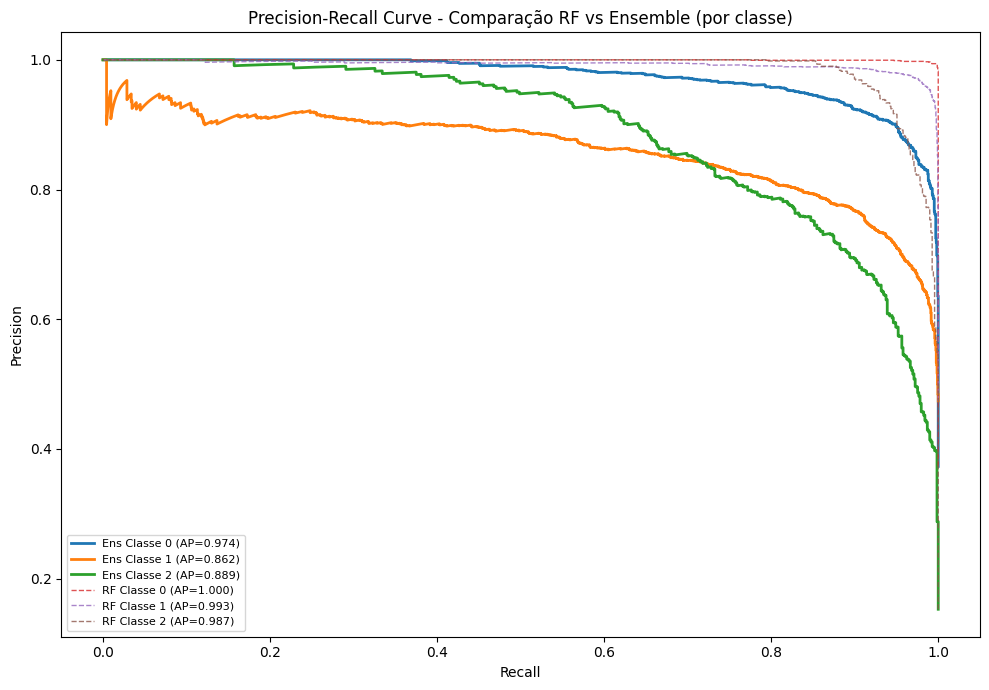

                   Random Forest  Super-Ensemble
Accuracy                  0.9749          0.8673
Precision (macro)         0.9726          0.8489
Recall (macro)            0.9636          0.8648
F1 (macro)                0.9679          0.8553
ROC-AUC                   0.9973          0.9529


In [15]:
from sklearn.metrics import average_precision_score

if 'estimators' not in globals():
    if 'voting_ensemble' in globals():
        estimators = getattr(voting_ensemble, 'estimators_', getattr(voting_ensemble, 'estimators', []))
    else:
        raise RuntimeError("Estimadores não encontrados. Treine o ensemble antes.")

def _select_X_for_estimator(est, X):
    if hasattr(est, "feature_names_in_"):
        return X.loc[:, est.feature_names_in_]
    return X

proba_list = []
for _, est in estimators:
    if hasattr(est, "predict_proba"):
        proba_list.append(est.predict_proba(_select_X_for_estimator(est, X_test)))
if proba_list:
    y_pred_proba_ensemble = np.mean(proba_list, axis=0)
else:
    y_pred_proba_ensemble = best_rf.predict_proba(X_test)

if 'y_pred_voting' not in globals():
    preds = []
    for _, est in estimators:
        if hasattr(est, "predict"):
            preds.append(est.predict(_select_X_for_estimator(est, X_test)))
    if preds:
        preds = np.vstack(preds).T
        y_pred_voting = np.apply_along_axis(lambda row: np.bincount(row).argmax(), 1, preds)
    else:
        y_pred_voting = best_rf.predict(X_test)

if 'y_test_bin' in globals():
    y_test_b = y_test_bin
else:
    from sklearn.preprocessing import label_binarize
    y_test_b = label_binarize(y_test, classes=best_rf.classes_)

n_classes = y_pred_proba_ensemble.shape[1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
cm_rf = confusion_matrix(y_test, best_rf.predict(X_test))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=ax1, cbar_kws={'label': 'Contagem'})
ax1.set_title('Matriz de Confusão - Random Forest')
ax1.set_xlabel('Predito'); ax1.set_ylabel('Real')

cm_ensemble = confusion_matrix(y_test, y_pred_voting)
sns.heatmap(cm_ensemble, annot=True, fmt='d', cmap='Greens', ax=ax2, cbar_kws={'label': 'Contagem'})
ax2.set_title('Matriz de Confusão - Super-Ensemble')
ax2.set_xlabel('Predito'); ax2.set_ylabel('Real')
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(10, 7))
for i in range(n_classes):
    fpr_i, tpr_i, _ = roc_curve(y_test_b[:, i], y_pred_proba_ensemble[:, i])
    auc_i = auc(fpr_i, tpr_i)
    ax.plot(fpr_i, tpr_i, lw=2, label=f'Classe {best_rf.classes_[i]} (AUC = {auc_i:.3f})')

for i in range(n_classes):
    fpr_i, tpr_i, _ = roc_curve(y_test_b[:, i], best_rf.predict_proba(X_test)[:, i])
    auc_i = auc(fpr_i, tpr_i)
    ax.plot(fpr_i, tpr_i, lw=1, linestyle='--', alpha=0.8, label=f'RF classe {best_rf.classes_[i]} (AUC = {auc_i:.3f})')

ax.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--', label='Random Classifier')
ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - Comparação RF vs Ensemble (por classe)')
ax.legend(loc="lower right", fontsize=9); plt.tight_layout(); plt.show()

roc_auc_rf = roc_auc_score(y_test, best_rf.predict_proba(X_test), multi_class='ovr', average='macro')
roc_auc_ens = roc_auc_score(y_test, y_pred_proba_ensemble, multi_class='ovr', average='macro')
print(f'ROC-AUC RF (macro OVR): {roc_auc_rf:.4f}')
print(f'ROC-AUC Ensemble (macro OVR): {roc_auc_ens:.4f}')

fig, ax = plt.subplots(figsize=(10, 7))
for i in range(n_classes):
    prec_i, rec_i, _ = precision_recall_curve(y_test_b[:, i], y_pred_proba_ensemble[:, i])
    ap_i = average_precision_score(y_test_b[:, i], y_pred_proba_ensemble[:, i])
    ax.plot(rec_i, prec_i, lw=2, label=f'Ens Classe {best_rf.classes_[i]} (AP={ap_i:.3f})')
for i in range(n_classes):
    prec_i, rec_i, _ = precision_recall_curve(y_test_b[:, i], best_rf.predict_proba(X_test)[:, i])
    ap_i = average_precision_score(y_test_b[:, i], best_rf.predict_proba(X_test)[:, i])
    ax.plot(rec_i, prec_i, lw=1, linestyle='--', alpha=0.8, label=f'RF Classe {best_rf.classes_[i]} (AP={ap_i:.3f})')

ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve - Comparação RF vs Ensemble (por classe)')
ax.legend(loc="best", fontsize=8); plt.tight_layout(); plt.show()

metrics_rf = globals().get('metrics_rf', {})
if not isinstance(metrics_rf, dict):
    metrics_rf = {}

metrics_ensemble = globals().get('metrics_ensemble', {})
if not isinstance(metrics_ensemble, dict):
    metrics_ensemble = {}

metrics_rf.setdefault('Accuracy', accuracy_score(y_test, y_pred_rf))
metrics_rf.setdefault('Precision (macro)', precision_score(y_test, y_pred_rf, average='macro'))
metrics_rf.setdefault('Recall (macro)', recall_score(y_test, y_pred_rf, average='macro'))
metrics_rf.setdefault('F1 (macro)', f1_score(y_test, y_pred_rf, average='macro'))
metrics_rf['ROC-AUC'] = roc_auc_rf

metrics_ensemble.setdefault('Accuracy', accuracy_score(y_test, y_pred_voting))
metrics_ensemble.setdefault('Precision (macro)', precision_score(y_test, y_pred_voting, average='macro'))
metrics_ensemble.setdefault('Recall (macro)', recall_score(y_test, y_pred_voting, average='macro'))
metrics_ensemble.setdefault('F1 (macro)', f1_score(y_test, y_pred_voting, average='macro'))
metrics_ensemble['ROC-AUC'] = roc_auc_ens

comparison_df = pd.DataFrame({
    'Random Forest': metrics_rf,
    'Super-Ensemble': metrics_ensemble
})
print(comparison_df.round(4))
